# Comparative Analysis of TEW, ESSE, ESSE with CGSM and no Scatter Correction

Comparative Analysis of TEW, ESSE, ESSE with CGSM, and No Scatter Correction
This notebook evaluates and compares the scatter correction methodologies available in PyTomography with the ESSE and ESSE + CGSM (Common Grid Scatter Modeling) methods implemented during my internship at the Institut de Cancérologie de l'Ouest (ICO).

We studied :
- No Scatter Correction: Baseline reconstruction.
- TEW (Triple Energy Window): The current clinical standard based on energy window subtraction.
- ESSE (Effective Source Scatter Estimation): A model-based approach using analytical kernels.
- ESSE + CGSM (Coarse Grid Scatter Model): An optimized implementation of the ESSE model, using lower-resolution images.


## Calculation

### Notebook initialization

In [125]:
# imports

import matplotlib.pyplot as plt
import torch
import numpy as np
import pytomography
from pytomography.io.SPECT import dicom
from pytomography.algorithms import OSEM
from pytomography.likelihoods import PoissonLogLikelihood
from pytomography.transforms.SPECT import SPECTAttenuationTransform, SPECTPSFTransform
from pytomography.transforms.shared import GaussianFilter
from pytomography.io.SPECT.shared import subsample_projections_and_modify_metadata
import os
from pytomography.utils import plot_utils, ESSEScatterModel, pad_object
import matplotlib.pyplot as plt
from ipywidgets import interact, fixed, IntSlider

from pytomography.projectors.SPECT.dualhead_system_matrix import SPECTSystemMatrix

In [126]:
is_available = torch.cuda.is_available()
print(f"GPU disponible : {is_available}")

if is_available:
    print(f"Nom du device : {torch.cuda.get_device_name(0)}")
    print(f"Nombre de GPUs : {torch.cuda.device_count()}")

GPU disponible : True
Nom du device : NVIDIA GeForce RTX 3050 Laptop GPU
Nombre de GPUs : 1


In [127]:
# Path initialization

if is_available:
    path = '/home/chloe/ICO/SPECT'  # Personal computer
else :
    path = 'K:\\Médecine Nucléaire Nantes\\DOSSIERS Nominatif PHYSICIENS\\Etudiants\\Chloé_Mallet_M2_2026\\SPECT' #ICO computer
pathCT = os.path.join(path, 'Lu177-NEMA-SymT2', 'CT')
# pathCT = os.path.join(path, 'Ac225-NEMA-SymT2', 'CT')
files_CT = [os.path.join(pathCT, file) for file in os.listdir(pathCT)]
file_NM = os.path.join(path, 'Lu177-NEMA-SymT2', 'projection_data.dcm')
# file_NM = os.path.join(path, 'Ac225-NEMA-SymT2', 'projection_data.IMA')

current_dir = os.getcwd()
DATADIR = os.path.join(current_dir, '../../../src/pytomography/data/NIST_attenuation_data')
FILE_WATER = os.path.join(DATADIR, 'water.csv')

In [128]:
# Parameters initialization

energy = 208.0
nb_iter=20
nb_subset=8
index_peak = 0
photopeak = dicom.get_projections(file_NM, index_peak=index_peak)

In [129]:
object_meta, proj_meta = dicom.get_metadata(file_NM)
projections = dicom.get_projections(file_NM)
attenuation_map = dicom.get_attenuation_map_from_CT_slices(files_CT, file_NM)
mu_water = pytomography.utils.get_mu_from_spectrum_interp(FILE_WATER, energy)

Given photopeak energy 208.0 keV and CT energy 130 keV from the CT DICOM header, the HU->mu conversion from the following configuration is used: 208.0 keV SPECT energy, 130 keV CT energy, and scanner model symbiat2


In [130]:
# Transforms initialization

att_transform = SPECTAttenuationTransform(attenuation_map=attenuation_map)
collimator_name = 'SY-ME'               #todo: automatiser la récupération du collimateur à partir des métadonnées 
energy_kev = energy
intrinsic_resolution=object_meta.dx
psf_meta = dicom.get_psfmeta_from_scanner_params(
        collimator_name,
        energy_kev,
        intrinsic_resolution=intrinsic_resolution
)
psf_transform = SPECTPSFTransform(psf_meta)

In [131]:
# Calculate objects

CT = dicom.open_multifile(files_CT)
affine_SPECT = dicom._get_affine_spect_projections(file_NM)
affine_CT = dicom._get_affine_multifile(files_CT)

### CT Scan information

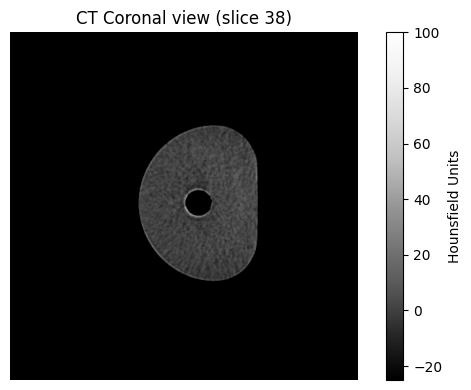

CT affichée au slice z=38
Range de valeurs CT: [-1024.0, 450.0] HU


In [132]:
# Plot CT scan

slice_idx = CT.shape[-1] // 2

plt.figure(figsize=(6, 4))
plt.title(f'CT Coronal view (slice {slice_idx})')
plt.imshow(CT.cpu().numpy()[:, :, slice_idx], cmap='Greys_r', origin='lower', vmin=-25, vmax=100)
plt.colorbar(label='Hounsfield Units')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"CT affichée au slice z={slice_idx}")
print(f"Range de valeurs CT: [{CT.min():.1f}, {CT.max():.1f}] HU")

In [133]:
slider_x = IntSlider(min=0, max=CT.shape[0]-1, step=1, value=CT.shape[0]//2, continuous_update=False)
slider_y = IntSlider(min=0, max=CT.shape[1]-1, step=1, value=CT.shape[1]//2, continuous_update=False)
slider_z = IntSlider(min=0, max=CT.shape[2]-1, step=1, value=CT.shape[2]//2, continuous_update=False)

def plot_interactive_CT(x, y, z):
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    CT_CPU = CT.cpu().numpy()

    # Views
    axes[0].imshow(CT_CPU[:, :, z], cmap='Greys_r', origin='lower', vmin=-25, vmax=100)
    axes[1].imshow(CT_CPU[:, y, :], cmap='Greys_r', origin='lower', vmin=-25, vmax=100)
    axes[2].imshow(CT_CPU[x, :, :], cmap='Greys_r', origin='lower', vmin=-25, vmax=100)

    # Columns titles
    axes[0].set_title(f'z={z}')
    axes[1].set_title(f'y={y}')
    axes[2].set_title(f'x={x}')

    for ax in axes.flatten():
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    plt.close(fig)

interact(plot_interactive_CT, x=slider_x, y=slider_y, z=slider_z)



interactive(children=(IntSlider(value=256, continuous_update=False, description='x', max=511), IntSlider(value…

<function __main__.plot_interactive_CT(x, y, z)>

### Reconstruction without scatter correction 

In [134]:
# Initialization

system_matrix_no_correction = SPECTSystemMatrix(
    obj2obj_transforms = [att_transform, psf_transform],
    proj2proj_transforms=[],
    object_meta=object_meta,
    proj_meta=proj_meta
)

likelihood_no_correction = PoissonLogLikelihood(system_matrix_no_correction, photopeak)
algorithm_no_correction = OSEM(likelihood_no_correction)

In [135]:
recon_no_correction = algorithm_no_correction(n_iters=nb_iter, n_subsets=nb_subset)

### Reconstruction with TEW

In [136]:
# Initialization

index_peak, index_lower, index_upper = 1, 0, 2
scatter_TEW = dicom.get_energy_window_scatter_estimate_projections(file_NM, projections, index_peak=index_peak, index_lower=index_lower, index_upper=index_upper, sigma_theta=2, sigma_r=0.48, sigma_z=0.48, proj_meta=proj_meta)

system_matrix_TEW = SPECTSystemMatrix(
        obj2obj_transforms = [att_transform, psf_transform],
        proj2proj_transforms = [],
        object_meta = object_meta,
        proj_meta = proj_meta)

likelihood_TEW = PoissonLogLikelihood(system_matrix_TEW, photopeak, scatter_TEW)
algorithm_TEW = OSEM(likelihood_TEW)

In [137]:
recon_TEW = algorithm_TEW(n_iters=nb_iter, n_subsets=nb_subset)

### Reconstruction with ESSE
(Kernels needed)

In [138]:
# Kernel generation
# todo : Récupérer les kernels ESSE réels quand j'y aurai accès
def get_fake_esse_kernels(grid_size):
    """
    Génère des kernels gaussiens avec la bonne taille.
    """
    Z, Y, X = grid_size
    kernels = torch.zeros((3, Z, Y, X))
  
    sigmas = [6.0, 5.0, 4.0] #écart type en nombre de voxels, pour chacun des noyaux
  
    for i, sigma in enumerate(sigmas):
        z = torch.arange(Z, dtype=torch.float32) - Z // 2
        y = torch.arange(Y, dtype=torch.float32) - Y // 2
        x = torch.arange(X, dtype=torch.float32) - X // 2
      
        zz, yy, xx = torch.meshgrid(z, y, x, indexing='ij')
        distance_sq = zz**2 + yy**2 + xx**2     # en unités de voxels
        kernels[i] = torch.exp(-distance_sq / (2 * sigma**2))
      
        kernels[i] /= kernels[i].sum()
  
    return kernels * 0.015

In [139]:
# Plot the kernels

# kernels = get_fake_esse_kernels(grid_size=padded_shape)


# collapsed_kernels = kernels.sum(dim=1) 

# def plot_kernels(data, title_prefix, cmap='hot'):
#     num_channels = data.shape[0]
#     fig, axes = plt.subplots(1, num_channels, figsize=(5 * num_channels, 5))
#     if num_channels == 1: axes = [axes]
    
#     for i in range(num_channels):
#         img = data[i, data.shape[1]//2] if data.ndim == 4 else data[i]
#         im = axes[i].imshow(img.detach().cpu().numpy(), cmap=cmap)
#         axes[i].set_title(f'{title_prefix} {i+1}')
#         plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
#     plt.tight_layout()
#     plt.show()

# # Affichage des deux états
# plot_kernels(kernels, "Original Kernel (Slice)")
# plot_kernels(collapsed_kernels, "Collapsed Kernel")

# print(f"Somme Originale: {kernels[0].sum().item():.2e}")
# print(f"Somme Collapsed: {collapsed_kernels[0].sum().item():.2e}")

In [140]:
# Initilization

esse = ESSEScatterModel(
    object_meta=object_meta,
    attenuation_map=attenuation_map,
    energy=208.4,
    mu_water=mu_water,
    kernels=get_fake_esse_kernels(
        grid_size=object_meta.padded_shape,
    )
)

system_matrix_ESSE = SPECTSystemMatrix(
    obj2obj_transforms = [att_transform, psf_transform],
    proj2proj_transforms = [],
    object_meta = object_meta,
    proj_meta = proj_meta,
    scatter_model=esse
)

likelihood_ESSE = PoissonLogLikelihood(system_matrix_ESSE, photopeak)
algorithm_ESSE = OSEM(likelihood_ESSE)

In [141]:
recon_ESSE = algorithm_ESSE(n_iters=nb_iter, n_subsets=nb_subset)

### Reconstruction with ESSE and CGSM
(Kernels needed)

In [142]:
# Initialization

CGSM_factor = 2

esseCGSM = ESSEScatterModel(
    object_meta=object_meta,
    attenuation_map=attenuation_map,
    energy=208.4,
    mu_water=mu_water,
    kernels=get_fake_esse_kernels(
        grid_size=object_meta.padded_shape,
    ),
    CGSM=CGSM_factor
)

system_matrix_ESSE_CGSM = SPECTSystemMatrix(
        obj2obj_transforms = [att_transform, psf_transform],
        proj2proj_transforms = [],
        object_meta = object_meta,
        proj_meta = proj_meta,
        scatter_model=esseCGSM  
        )

likelihood_ESSE_CGSM = PoissonLogLikelihood(system_matrix_ESSE_CGSM, photopeak)
algorithm_ESSE_CGSM = OSEM(likelihood_ESSE_CGSM)

In [143]:
# recon_ESSE_CGSM = algorithm_ESSE_CGSM(n_iters=nb_iter, n_subsets=nb_subset)

## Results

#### Plot functions initialization

In [144]:
def plot_interactive_spect(x, y, z, recon1, recon2, vmax, label1, label2):
    recon1_CPU = recon1.cpu().numpy() if hasattr(recon1, 'is_cuda') and recon1.is_cuda else (recon1.numpy() if hasattr(recon1, 'numpy') else recon1)
    recon2_CPU = recon2.cpu().numpy() if hasattr(recon2, 'is_cuda') and recon2.is_cuda else (recon2.numpy() if hasattr(recon2, 'numpy') else recon2)

    fig, axes = plt.subplots(3, 4, figsize=(16, 12), 
                             gridspec_kw={'width_ratios': [0.3, 1, 1, 1]})
    
    rows = [label1, label2, f'Difference\n({label1} - {label2})']
    
    # 1. RECONSTRUCTION 1
    axes[0, 1].imshow(recon1_CPU[x, :, :], cmap=plot_utils.pet_cmap, origin='lower', vmin=0, vmax=vmax)
    axes[0, 2].imshow(recon1_CPU[:, y, :], cmap=plot_utils.pet_cmap, origin='lower', vmin=0, vmax=vmax)
    axes[0, 3].imshow(recon1_CPU[:, :, z], cmap=plot_utils.pet_cmap, origin='lower', vmin=0, vmax=vmax)

    

    # 2. RECONSTRUCTION 2
    axes[1, 1].imshow(recon2_CPU[x, :, :], cmap=plot_utils.pet_cmap, origin='lower', vmin=0, vmax=vmax)
    axes[1, 2].imshow(recon2_CPU[:, y, :], cmap=plot_utils.pet_cmap, origin='lower', vmin=0, vmax=vmax)
    axes[1, 3].imshow(recon2_CPU[:, :, z], cmap=plot_utils.pet_cmap, origin='lower', vmin=0, vmax=vmax)
    

    # 3. DIFFÉRENCE
    diff = recon1_CPU - recon2_CPU
    axes[2, 1].imshow(diff[x, :, :], cmap='RdBu_r', origin='lower', vmin=-vmax, vmax=vmax)
    axes[2, 2].imshow(diff[:, y, :], cmap='RdBu_r', origin='lower', vmin=-vmax, vmax=vmax)
    axes[2, 3].imshow(diff[:, :, z], cmap='RdBu_r', origin='lower', vmin=-vmax, vmax=vmax)
    
    # Columns titles
    axes[0, 1].set_title(f'x={x}')
    axes[0, 2].set_title(f'y={y}')
    axes[0, 3].set_title(f'z={z}')

    plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, wspace=0.02, hspace=0.1)

    # Line titles
    for i in range(3):
        axes[i, 0].set_axis_off()
        axes[i, 0].text(0.5, 0.5, rows[i], fontsize=12, 
                        ha='center', va='center', rotation=0)

    for ax in axes.flatten():
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    plt.close(fig)


In [145]:
def plot_comparative_spect(recon1, recon2, vmax, label1, label2, slice_idx=None):
    if slice_idx is None:
        slice_idx = recon1.shape[-1] // 2
    # vmax_comum = max(recon.max().item(), reconCGSM.max().item())

    recon1_CPU = recon1.cpu().numpy() if hasattr(recon1, 'is_cuda') and recon1.is_cuda else (recon1.numpy() if hasattr(recon1, 'numpy') else recon1)
    recon2_CPU = recon2.cpu().numpy() if hasattr(recon2, 'is_cuda') and recon2.is_cuda else (recon2.numpy() if hasattr(recon2, 'numpy') else recon2)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # RECONSTRUCTION 1
    im1 = axes[0].imshow(recon1_CPU[:, :, slice_idx], cmap=plot_utils.pet_cmap, vmin=0, vmax=vmax, origin='lower')
    axes[0].set_title(f'{label1} ({nb_iter} iter, {nb_subset} subsets)')
    axes[0].axis('off')
    plt.colorbar(im1, ax=axes[0], label='Intensity')

    # RECONSTRUCTION 2
    im2 = axes[1].imshow(recon2_CPU[:, :, slice_idx], cmap=plot_utils.pet_cmap, vmin=0, vmax=vmax, origin='lower')
    axes[1].set_title(f'{label2} ({nb_iter} iter, {nb_subset} subsets)')
    axes[1].axis('off')
    plt.colorbar(im2, ax=axes[1], label='Intensity')

    # DIFFÉRENCE
    diff = recon1_CPU - recon2_CPU
    im3 = axes[2].imshow(diff[:, :, slice_idx], cmap='RdBu_r', origin='lower')
    axes[2].set_title(f'Différence ({label1} - {label2})')
    axes[2].axis('off')
    plt.colorbar(im3, ax=axes[2], label='Δ Intensity')

#### TEW - None

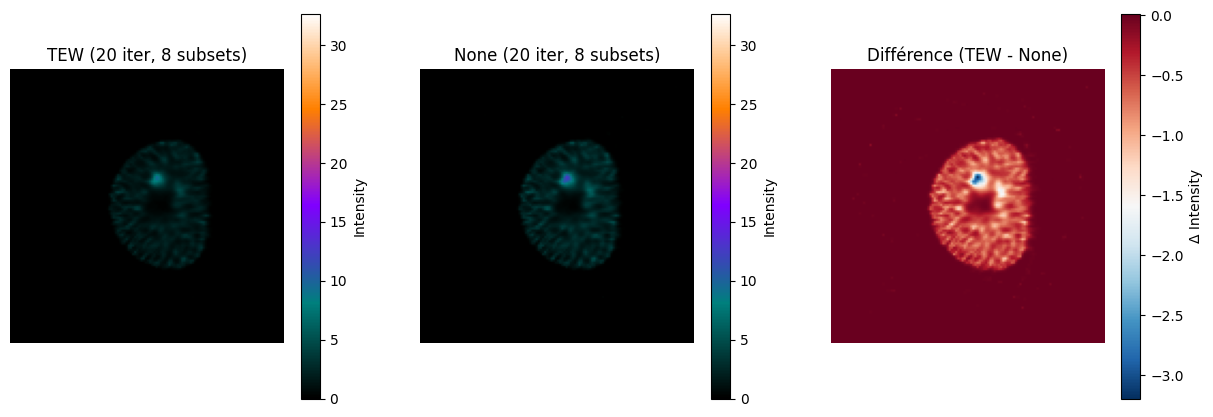

In [146]:
plot_comparative_spect(recon_TEW, recon_no_correction, vmax=max(recon_TEW.max(), recon_no_correction.max()), label1="TEW", label2="None")

#### ESSE - None

In [147]:
slider_x = IntSlider(min=0, max=recon_no_correction.shape[0]-1, step=1, value=recon_no_correction.shape[0]//2, continuous_update=False)
slider_y = IntSlider(min=0, max=recon_no_correction.shape[1]-1, step=1, value=recon_no_correction.shape[1]//2, continuous_update=False)
slider_z = IntSlider(min=0, max=recon_no_correction.shape[2]-1, step=1, value=recon_no_correction.shape[2]//2, continuous_update=False)

r1_np = recon_ESSE.cpu().detach().numpy()
r2_np = recon_no_correction.cpu().detach().numpy()
vmax_val = max(r1_np.max(), r2_np.max())

interact(
    plot_interactive_spect, 
    x=slider_x, 
    y=slider_y, 
    z=slider_z, 
    recon1=fixed(r1_np),
    recon2=fixed(r2_np), 
    vmax=fixed(vmax_val),
    label1=fixed("ESSE"),
    label2=fixed("None")
)

interactive(children=(IntSlider(value=64, continuous_update=False, description='x', max=127), IntSlider(value=…

<function __main__.plot_interactive_spect(x, y, z, recon1, recon2, vmax, label1, label2)>

ESSE reconstruction value range: [0.000, 30.431]


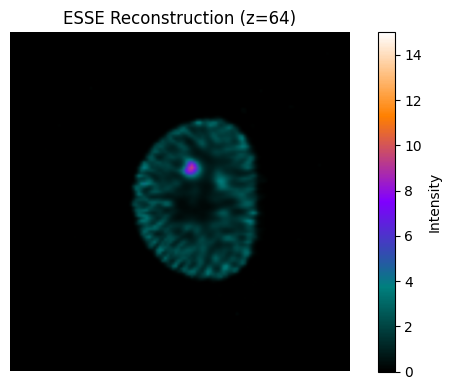

Sum of voxels in recon_no_correction: 2.02e+05
Sum of voxels in recon_TEW: 1.49e+05
Sum of voxels in recon_ESSE: 1.48e+05


In [148]:
recon_max = recon_ESSE.max().item()
recon_min = recon_ESSE.min().item()
print(f"ESSE reconstruction value range: [{recon_min:.3f}, {recon_max:.3f}]")

SPECT_imshow_kwargs = {
    'cmap': plot_utils.pet_cmap,
    'interpolation': 'Gaussian',
    'alpha': 1,
    'vmin': recon_min,
    'vmax': 15,
    'zorder': 1,
    'origin': 'lower'
}

slice_idx = recon_ESSE.shape[-1] // 2

plt.figure(figsize=(6, 4))
plt.title(f'ESSE Reconstruction (z={slice_idx})')
plt.imshow(recon_ESSE.cpu()[:, :, slice_idx], **SPECT_imshow_kwargs)
plt.colorbar(label='Intensity')
plt.axis('off')

plt.tight_layout()
plt.show()

#print the sum of all voxels in the reconstructions
print(f"Sum of voxels in recon_no_correction: {recon_no_correction.sum().item():.2e}")
print(f"Sum of voxels in recon_TEW: {recon_TEW.sum().item():.2e}")
print(f"Sum of voxels in recon_ESSE: {recon_ESSE.sum().item():.2e}")

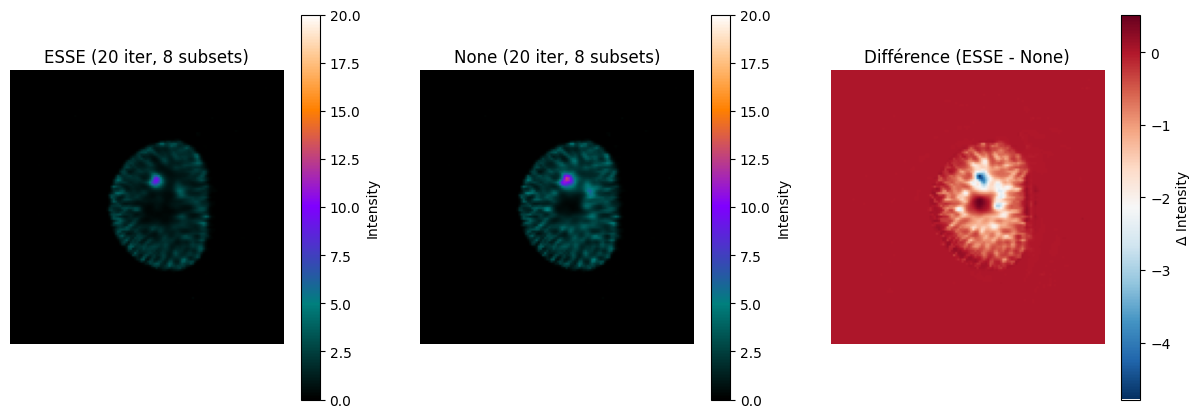

In [149]:
# plot_comparative_spect(recon_ESSE, recon_no_correction, vmax=max(recon_ESSE.max(), recon_no_correction.max()), label1="ESSE", label2="None")
plot_comparative_spect(recon_ESSE, recon_no_correction, vmax=20, label1="ESSE", label2="None")

#### ESSE - TEW

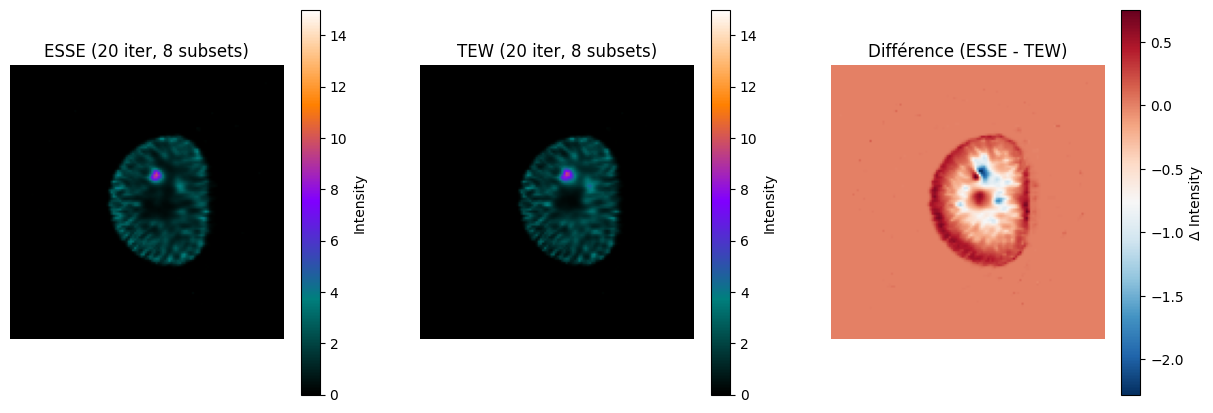

In [150]:
plot_comparative_spect(recon_ESSE, recon_TEW, vmax=15, label1="ESSE", label2="TEW")

#### CGSM

In [151]:
# plot_comparative_spect(recon_ESSE, recon_ESSE_CGSM, vmax=vmax_val, label1="ESSE", label2="ESSE + CGSM")

## Cartes de diffusé

### Cartes du diffusé ESSE

En passant l'objet reconstruit sans correction de diffusé :

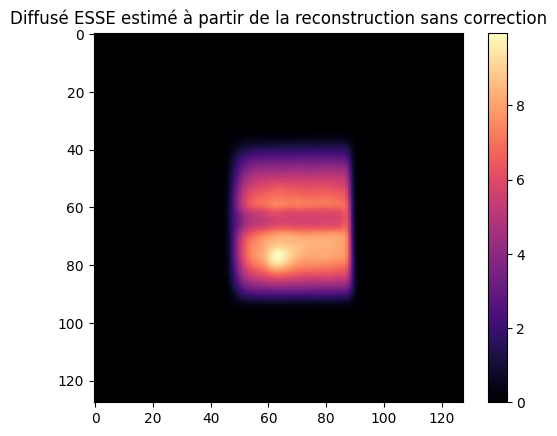

In [152]:
# Projection du diffusé ESSE basé sur l'objet SANS correction
# Cela montre le diffusé "initial" estimé par le modèle physique
proj_total_base = system_matrix_ESSE.forward(recon_no_correction)
proj_primary_base = system_matrix_no_correction.forward(recon_no_correction)

scatter_map_esse_from_no_corr = proj_total_base - proj_primary_base

# Visualisation
plt.imshow(scatter_map_esse_from_no_corr[0].cpu().detach().numpy(), cmap='magma')
plt.title("Diffusé ESSE estimé à partir de la reconstruction sans correction")
plt.colorbar()
plt.show()


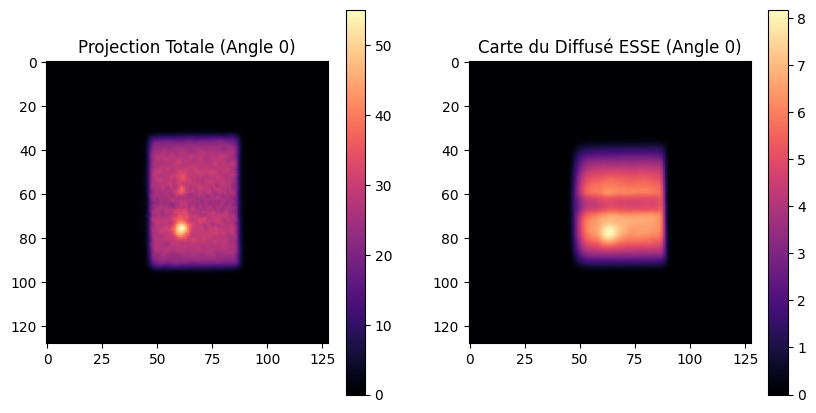

In [153]:

# Projection du diffusé ESSE basé sur l'objet AVEC correction
proj_total = system_matrix_ESSE.forward(recon_ESSE)

# Projection primaire (Uniquement Atténuation + PSF)
proj_primary = system_matrix_no_correction.forward(recon_ESSE)

# 2. Extraction de la carte du diffusé par différence
# scatter_map = (H_p + H_s)f - H_p*f = H_s*f
scatter_map_esse = proj_total - proj_primary

angle_idx = 0
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title(f"Projection Totale (Angle {angle_idx})")
plt.imshow(proj_total[angle_idx].cpu().detach().numpy(), cmap='magma')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.title(f"Carte du Diffusé ESSE (Angle {angle_idx})")
plt.imshow(scatter_map_esse[angle_idx].cpu().detach().numpy(), cmap='magma')
plt.colorbar()
plt.show()

### Cartes du diffusé TEW

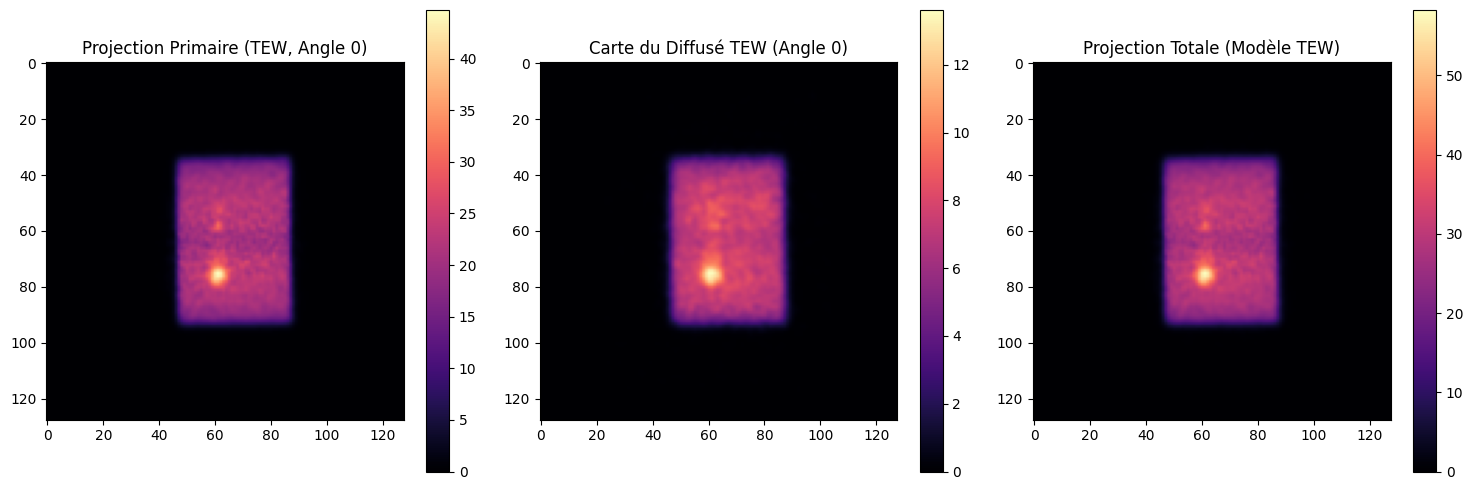

In [154]:
# 1. La carte du diffusé TEW est déjà pré-calculée dans votre cellule 11
# Elle ne dépend pas de l'objet, mais des données acquises.
scatter_map_tew = scatter_TEW

# 2. Calcul de la projection primaire sur l'objet reconstruit TEW
proj_primary_tew = system_matrix_TEW.forward(recon_TEW)

# 3. La projection totale modélisée par TEW est la somme des deux
proj_total_tew = proj_primary_tew + scatter_map_tew

# Visualisation (Angle 0)
angle_idx = 0
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title(f"Projection Primaire (TEW, Angle {angle_idx})")
plt.imshow(proj_primary_tew[angle_idx].cpu().detach().numpy(), cmap='magma')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.title(f"Carte du Diffusé TEW (Angle {angle_idx})")
plt.imshow(scatter_map_tew[angle_idx].cpu().detach().numpy(), cmap='magma')
plt.colorbar()

plt.subplot(1, 3, 3)
plt.title("Projection Totale (Modèle TEW)")
plt.imshow(proj_total_tew[angle_idx].cpu().detach().numpy(), cmap='magma')
plt.colorbar()

plt.tight_layout()
plt.show()

### Difference

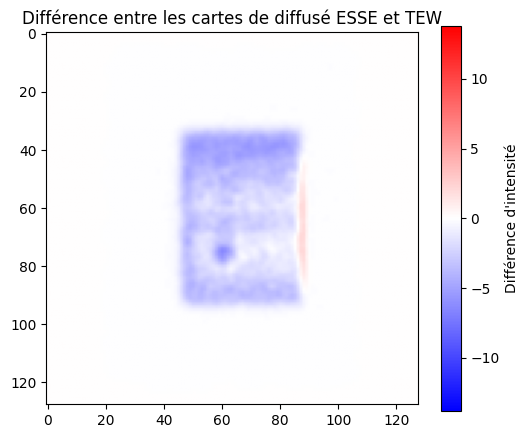

In [155]:
# Afficher la différence entre les cartes de diffusé ESSE et TEW
diff_scatter = scatter_map_esse - scatter_map_tew
plt.figure(figsize=(6, 5))
plt.title("Différence entre les cartes de diffusé ESSE et TEW")
plt.imshow(diff_scatter[angle_idx].cpu().detach().numpy(), cmap='bwr', vmin=-diff_scatter.abs().max().item(), vmax=diff_scatter.abs().max().item())
plt.colorbar(label='Différence d\'intensité')
plt.show()  